In [73]:
import pandas as pd 
import numpy as np 

In [74]:
df = pd.read_csv("../data/heart_disease.csv")

In [75]:
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


In [76]:
df.tail()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
995,56,Female,269,111,86,Never,Heavy,5,No,Yes,Yes,10,120,No,Non-anginal Pain,1
996,78,Female,334,145,76,Never,NaN,6,No,No,No,10,196,Yes,Typical Angina,1
997,79,Male,151,179,81,Never,Moderate,4,Yes,No,Yes,8,189,Yes,Asymptomatic,0
998,60,Female,326,151,68,Former,NaN,8,Yes,Yes,No,5,174,Yes,Atypical Angina,1
999,53,Male,226,116,82,Current,NaN,6,No,No,Yes,5,161,Yes,Asymptomatic,1


In [77]:
X = df.drop("Heart Disease",axis=1)
y = df['Heart Disease']

In [78]:
numerical_faetures = df.select_dtypes(include = ["int64","float64"]).columns
categorical_features = df.select_dtypes(include = ["str"]).columns

In [79]:
numerical_faetures

Index(['Age', 'Cholesterol', 'Blood Pressure', 'Heart Rate', 'Exercise Hours',
       'Stress Level', 'Blood Sugar', 'Heart Disease'],
      dtype='str')

In [81]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.20,
    random_state = 42
)

In [84]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),numerical_features),
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [88]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train_processed,y_train)

y_pred = knn.predict(X_test_processed)

In [89]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report

print("accuracy:",accuracy_score(y_test,y_pred))
print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("Classification report:",classification_report(y_test,y_pred))

accuracy: 0.86
precision: 0.8048780487804879
recall: 0.8461538461538461
f1: 0.825
Classification report:               precision    recall  f1-score   support

           0       0.90      0.87      0.88       122
           1       0.80      0.85      0.82        78

    accuracy                           0.86       200
   macro avg       0.85      0.86      0.85       200
weighted avg       0.86      0.86      0.86       200



In [93]:
k_values = [1,3,5,7,9,11,13,15,17,21]

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

for k in k_values:
    loop_knn = KNeighborsClassifier(
        n_neighbors=k
    )

    loop_knn.fit(X_train_processed,y_train)

    loop_pred = loop_knn.predict(X_test_processed)

    accuracy_scores.append(accuracy_score(y_test,loop_pred))
    precision_scores.append(precision_score(y_test,loop_pred))
    recall_scores.append(recall_score(y_test,loop_pred))
    f1_scores.append(f1_score(y_test,loop_pred))
    
    

In [94]:
results = pd.DataFrame(
    {
        "k_values":k_values,
        "accuracy_scores":accuracy_scores,
        "precision_scores":precision_scores,
        "recall_scores":recall_scores,
        "f1_scores":f1_scores
    }
)

print(results)

   k_values  accuracy_scores  precision_scores  recall_scores  f1_scores
0         1            0.795          0.740260       0.730769   0.735484
1         3            0.885          0.866667       0.833333   0.849673
2         5            0.860          0.804878       0.846154   0.825000
3         7            0.885          0.866667       0.833333   0.849673
4         9            0.875          0.853333       0.820513   0.836601
5        11            0.905          0.915493       0.833333   0.872483
6        13            0.900          0.914286       0.820513   0.864865
7        15            0.900          0.902778       0.833333   0.866667
8        17            0.885          0.887324       0.807692   0.845638
9        21            0.900          0.902778       0.833333   0.866667


In [99]:
best_index = np.argmax(f1_scores)
print(best_index)
best_k_value = k_values[best_index]

print(best_k_value)

5
11


In [100]:
print("best_k_value:",k_values[best_index])
print("best_accuracy_score",accuracy_scores[best_index])
print("best_precision_score",precision_scores[best_index])
print("best_recall_score",recall_scores[best_index])
print("best_f1_score",f1_scores[best_index])

best_k_value: 11
best_accuracy_score 0.905
best_precision_score 0.9154929577464789
best_recall_score 0.8333333333333334
best_f1_score 0.87248322147651


In [102]:
final_knn = KNeighborsClassifier(
    n_neighbors=best_k_value
)

# Train the final model
final_knn.fit(
    X_train_processed,
    y_train
)

# Make final predictions
final_pred = final_knn.predict(
    X_test_processed
)

In [103]:
print("Best accuracy:",accuracy_score(y_test,final_pred))
print("Best precision:",precision_score(y_test,final_pred))
print("Best recall:",recall_score(y_test,final_pred))
print("Best f1:",f1_score(y_test,final_pred))
print("Best Classification report:",classification_report(y_test,final_pred))

Best accuracy: 0.905
Best precision: 0.9154929577464789
Best recall: 0.8333333333333334
Best f1: 0.87248322147651
Best Classification report:               precision    recall  f1-score   support

           0       0.90      0.95      0.92       122
           1       0.92      0.83      0.87        78

    accuracy                           0.91       200
   macro avg       0.91      0.89      0.90       200
weighted avg       0.91      0.91      0.90       200



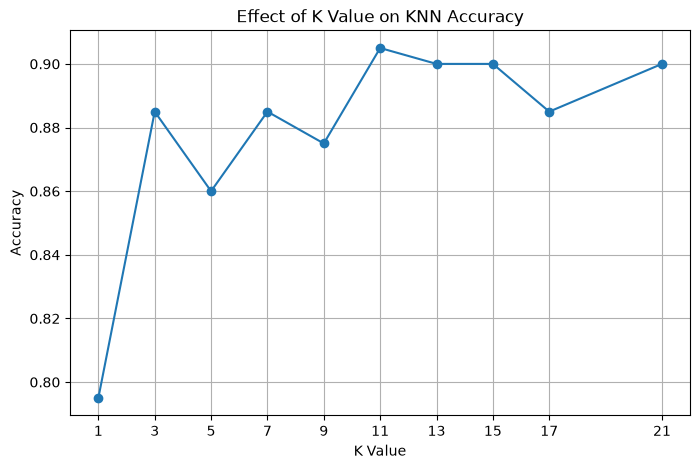

In [104]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracy_scores,
    marker="o"
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Effect of K Value on KNN Accuracy")
plt.xticks(k_values)
plt.grid()
plt.show()